## **Lab Problem Statement 6**
### Statistical Analysis of Physical Characteristics of Palmer Penguins

### Objective
To perform a comprehensive statistical analysis of the Palmer Penguins
dataset using descriptive statistics, hypothesis testing, ANOVA,
non-parametric tests, effect-size estimation, and visualization.

### Main Variables
- Species
- Sex
- Body Mass
- Flipper Length
- Bill Length
- Bill Depth

In [1]:
# Install packages
install.packages(c(
  "palmerpenguins",
  "dplyr",
  "ggplot2",
  "moments",
  "car",
  "effectsize"
))

# Load libraries
library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(effectsize)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [2]:
# Load Palmer Penguins dataset
data("penguins")

# Display first few observations
head(penguins)

# Display structure
str(penguins)

# Display dimensions
dim(penguins)

# Summary
summary(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


[1] 344   8

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

In [3]:
# Number of missing values in each variable
colSums(is.na(penguins))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

In [4]:
penguins_clean <- penguins %>%
  filter(
    !is.na(body_mass_g),
    !is.na(sex)
  )

# Check dimensions
dim(penguins_clean)

# Check missing values again
colSums(is.na(penguins_clean))

[1] 333   8

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 0                 0 
flipper_length_mm       body_mass_g               sex              year 
                0                 0                 0                 0

In [5]:
body_mass <- penguins_clean$body_mass_g

mean_mass <- mean(body_mass)
median_mass <- median(body_mass)
min_mass <- min(body_mass)
max_mass <- max(body_mass)
variance_mass <- var(body_mass)
sd_mass <- sd(body_mass)
q1_mass <- quantile(body_mass, 0.25)
q3_mass <- quantile(body_mass, 0.75)
iqr_mass <- IQR(body_mass)
skewness_mass <- skewness(body_mass)
kurtosis_mass <- kurtosis(body_mass)

descriptive_stats <- data.frame(
  Statistic = c(
    "Mean",
    "Median",
    "Minimum",
    "Maximum",
    "Variance",
    "Standard Deviation",
    "Q1",
    "Q3",
    "IQR",
    "Skewness",
    "Kurtosis"
  ),
  Value = c(
    mean_mass,
    median_mass,
    min_mass,
    max_mass,
    variance_mass,
    sd_mass,
    q1_mass,
    q3_mass,
    iqr_mass,
    skewness_mass,
    kurtosis_mass
  )
)

descriptive_stats

Statistic,Value
<chr>,<dbl>
Mean,4.207057e+03
Median,4.050000e+03
Minimum,2.700000e+03
Maximum,6.300000e+03
Variance,6.483725e+05
Standard Deviation,8.052158e+02
Q1,3.550000e+03
Q3,4.775000e+03
IQR,1.225000e+03


In [6]:
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    n = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

species_stats

species,n,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,146,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,119,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


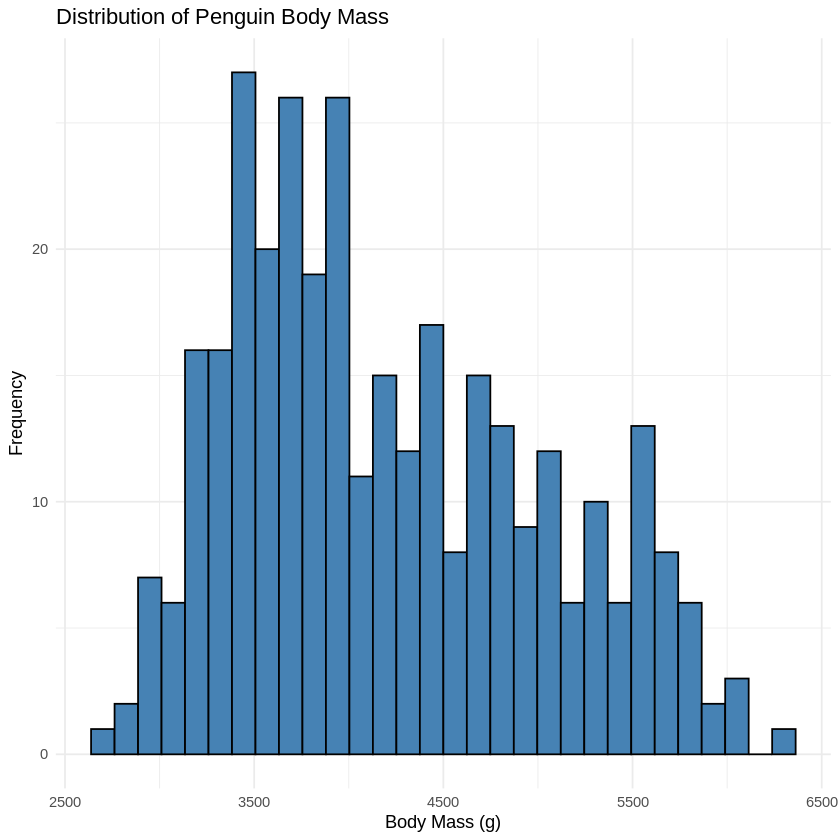

In [7]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    fill = "steelblue",
    color = "black"
  ) +
  labs(
    title = "Distribution of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

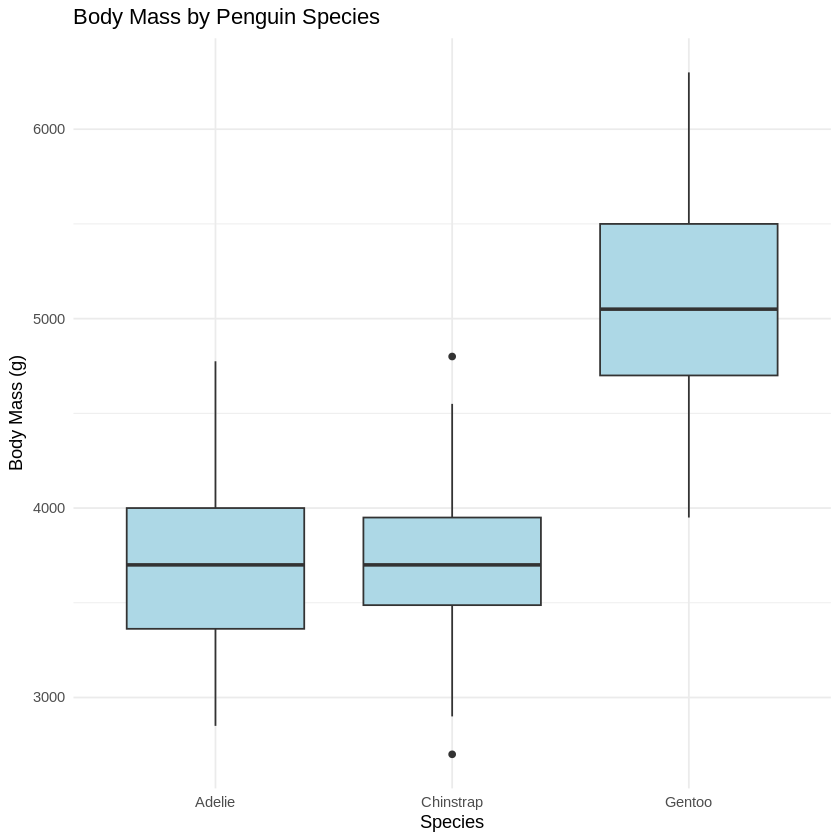

In [8]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

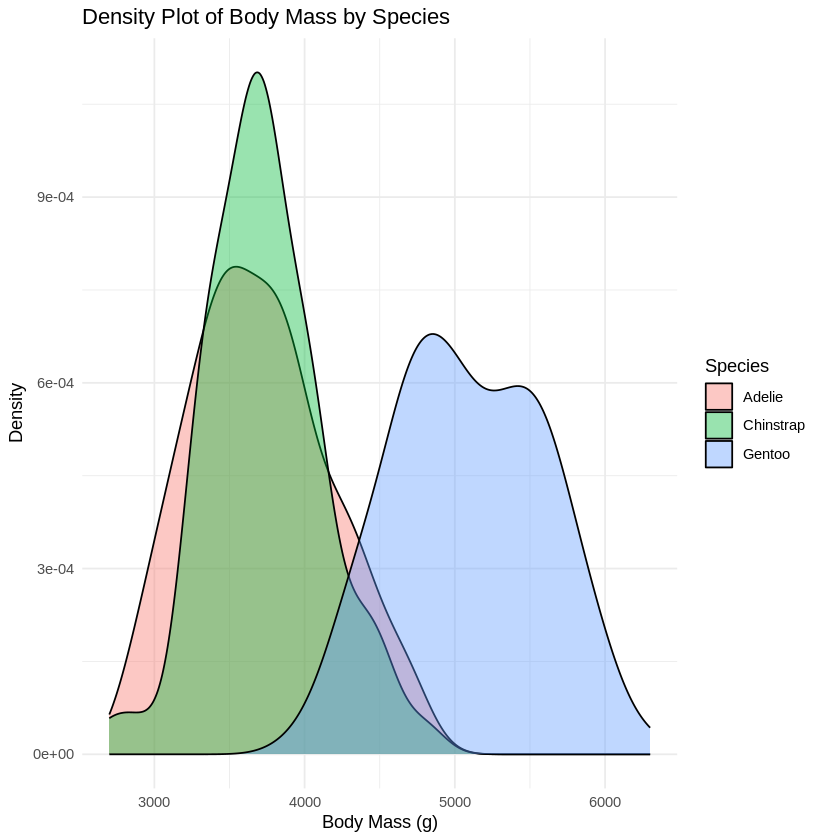

In [9]:
ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()

### Hypotheses

**Null Hypothesis (H₀):**

The mean body mass of male penguins is equal to the mean body mass
of female penguins.

H₀: μ_male = μ_female

**Alternative Hypothesis (H₁):**

The mean body mass of male penguins is different from the mean body
mass of female penguins.

H₁: μ_male ≠ μ_female

Significance level:

α = 0.05

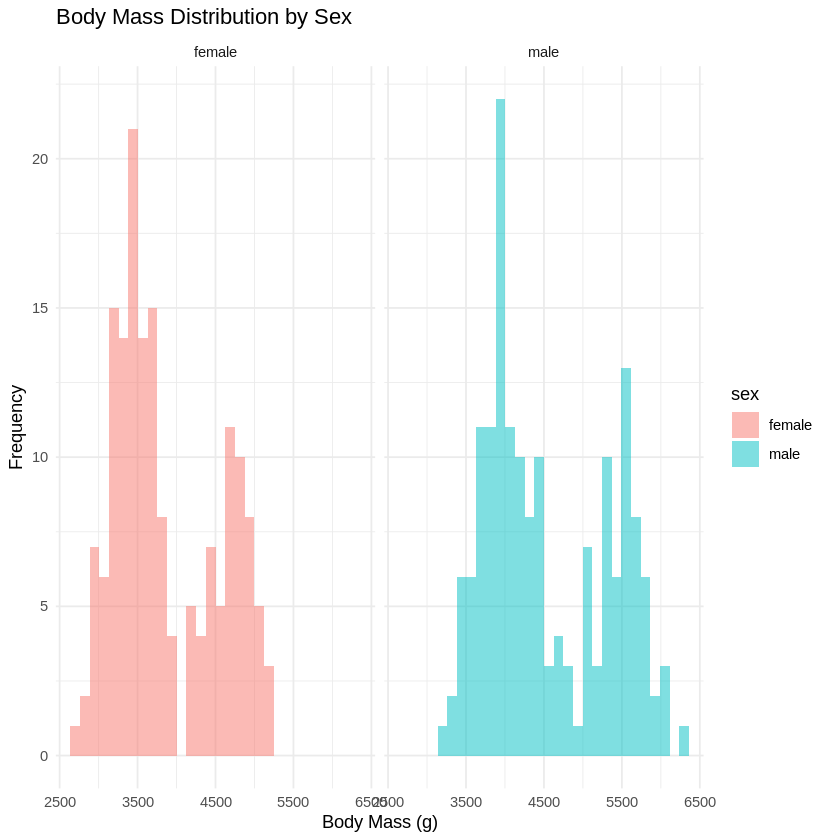

In [10]:
ggplot(penguins_clean, aes(x = body_mass_g, fill = sex)) +
  geom_histogram(
    bins = 30,
    alpha = 0.5,
    position = "identity"
  ) +
  facet_wrap(~sex) +
  labs(
    title = "Body Mass Distribution by Sex",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

In [11]:
# Shapiro-Wilk test
male_mass <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_mass <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

shapiro_male <- shapiro.test(male_mass)
shapiro_female <- shapiro.test(female_mass)

shapiro_male
shapiro_female


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


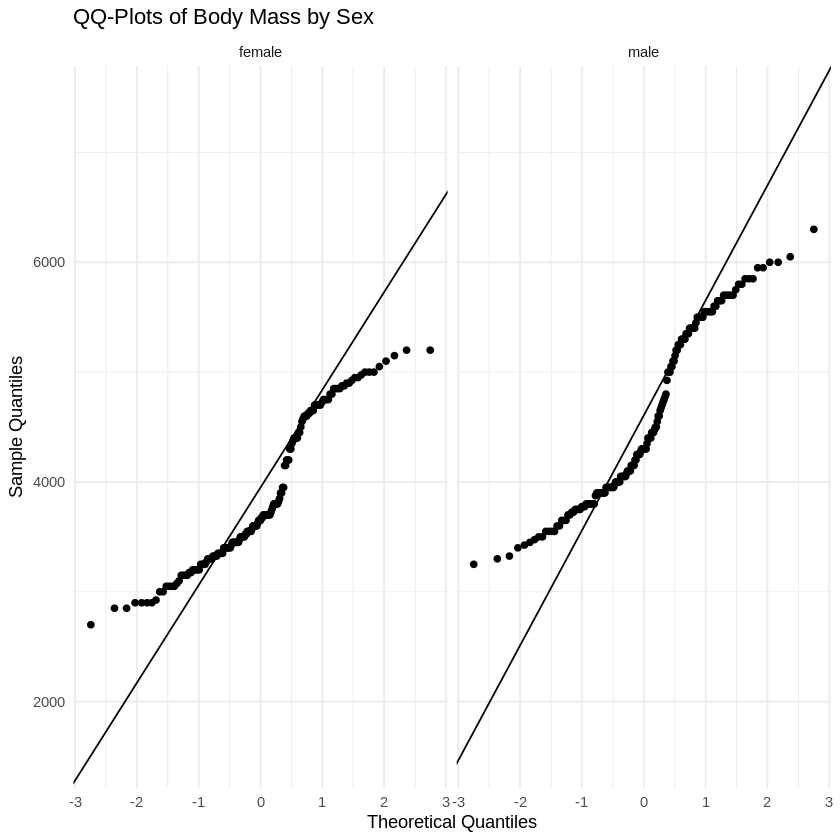

In [12]:
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~sex) +
  labs(
    title = "QQ-Plots of Body Mass by Sex",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()

In [13]:
t_test_result <- t.test(
  body_mass_g ~ sex,
  data = penguins_clean,
  var.equal = FALSE,
  conf.level = 0.95
)

t_test_result


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [14]:
# Cohen's d
cohen_d_result <- cohens_d(
  body_mass_g ~ sex,
  data = penguins_clean
)

cohen_d_result

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


In [15]:
p_value_ttest <- t_test_result$p.value

if (p_value_ttest < 0.05) {
  print("Reject H0: Male and female penguins have significantly different mean body masses.")
} else {
  print("Fail to reject H0: No statistically significant difference in mean body mass was found.")
}

[1] "Reject H0: Male and female penguins have significantly different mean body masses."


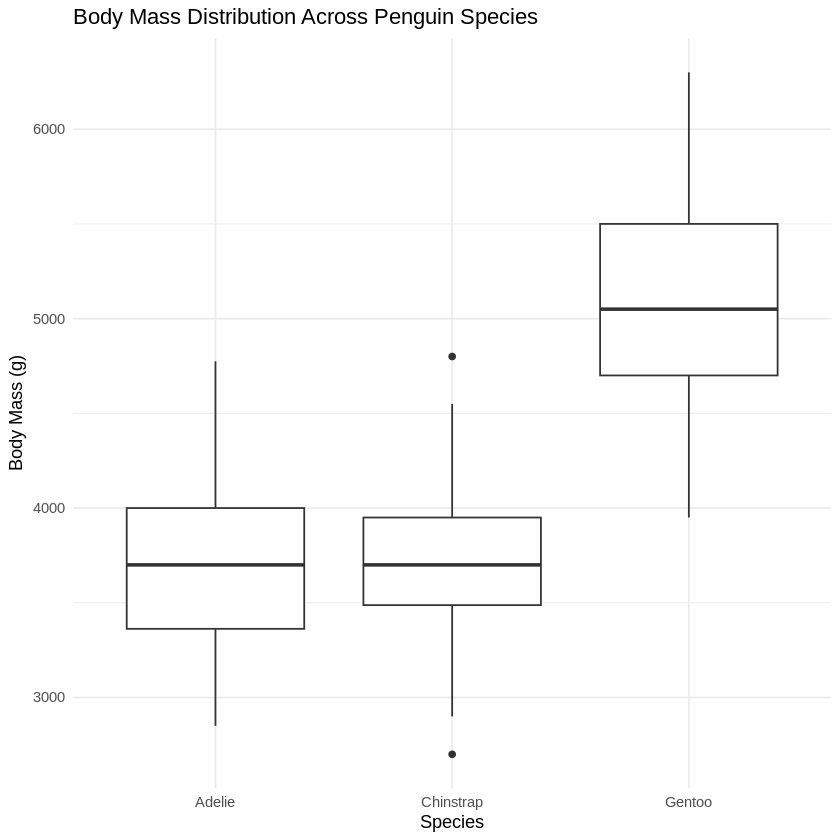

In [16]:
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass Distribution Across Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

In [17]:
penguins_clean %>%
  group_by(species) %>%
  summarise(
    Shapiro_W = shapiro.test(body_mass_g)$statistic,
    p_value = shapiro.test(body_mass_g)$p.value
  )

species,Shapiro_W,p_value
<fct>,<dbl>,<dbl>
Adelie,0.9811608,0.0423224
Chinstrap,0.9844938,0.5605082
Gentoo,0.9860612,0.2605247


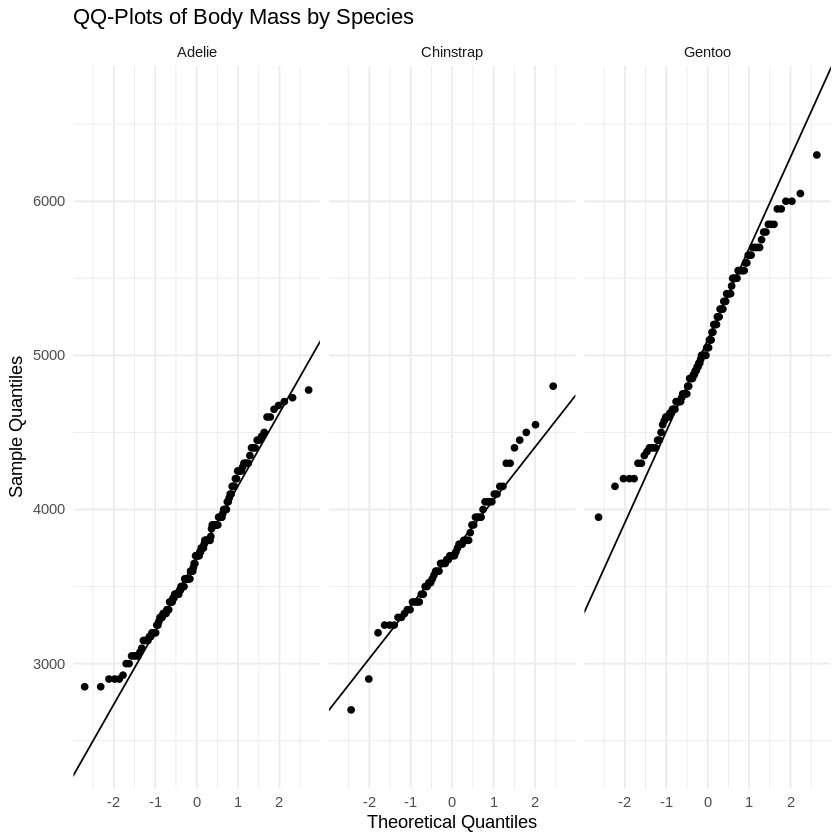

In [18]:
ggplot(penguins_clean, aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ-Plots of Body Mass by Species",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()

In [19]:
levene_result <- leveneTest(
  body_mass_g ~ species,
  data = penguins_clean
)

levene_result

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [20]:
# One-way ANOVA
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [21]:
# Tukey HSD
tukey_result <- TukeyHSD(anova_model)

tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


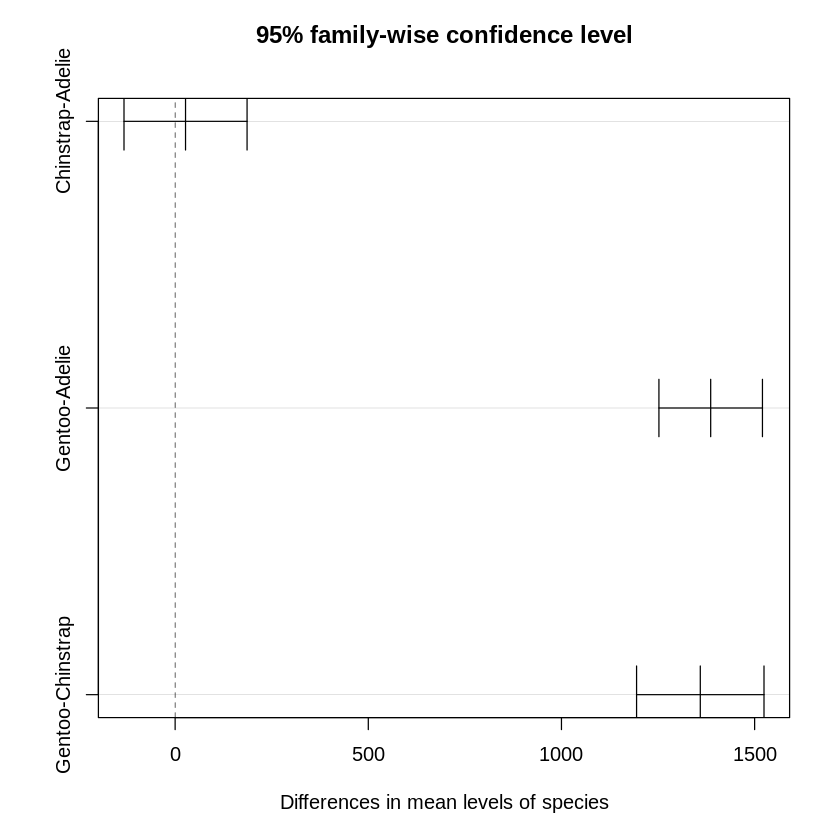

In [22]:
plot(tukey_result)

In [23]:
anova_p <- summary(anova_model)[[1]][["Pr(>F)"]][1]

if (anova_p < 0.05) {
  print("Reject H0: Mean body mass differs significantly among penguin species.")
} else {
  print("Fail to reject H0: No significant difference in mean body mass among species.")
}

[1] "Reject H0: Mean body mass differs significantly among penguin species."


In [24]:
# Kruskal-Wallis Test
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


In [25]:
# Compare ANOVA and Kruskal-Wallis
cat("ANOVA p-value:", anova_p, "\n")
cat("Kruskal-Wallis p-value:", kruskal_result$p.value, "\n")

ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 


In [26]:
# Two-way ANOVA
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

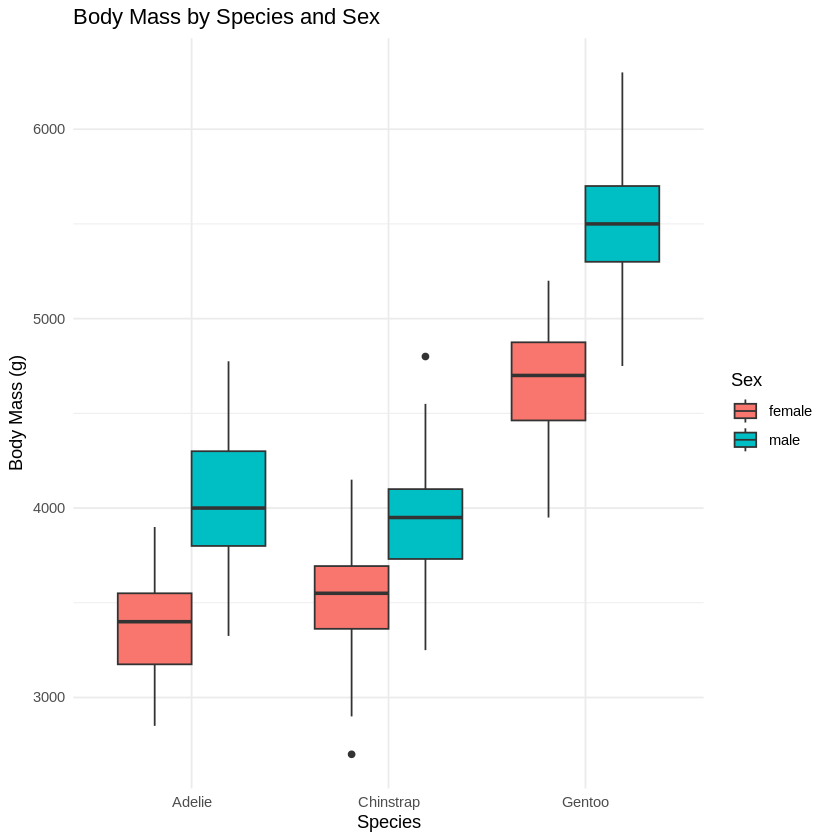

In [27]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = body_mass_g,
    fill = sex
  )
) +
  geom_boxplot(position = position_dodge()) +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex"
  ) +
  theme_minimal()

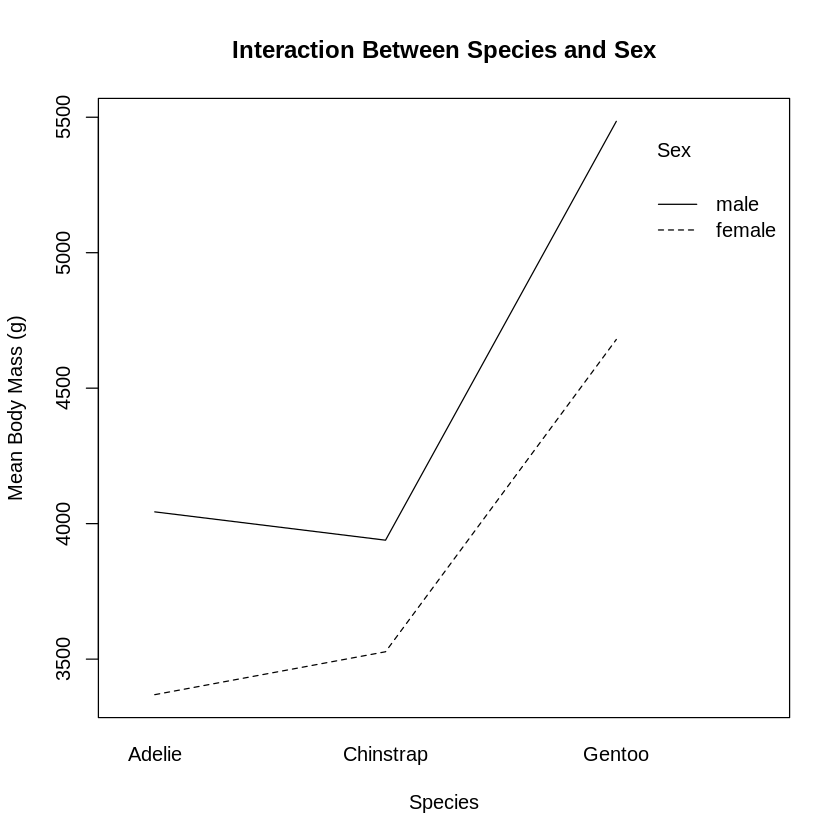

In [28]:
interaction.plot(
  penguins_clean$species,
  penguins_clean$sex,
  penguins_clean$body_mass_g,
  xlab = "Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Interaction Between Species and Sex"
)

In [29]:
flipper_data <- penguins %>%
  filter(!is.na(flipper_length_mm))

In [30]:
# Species-wise flipper statistics
flipper_stats <- flipper_data %>%
  group_by(species) %>%
  summarise(
    n = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm)
  )

flipper_stats

species,n,Mean,Median,SD,Minimum,Maximum
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
Adelie,151,189.9536,190,6.539457,172,210
Chinstrap,68,195.8235,196,7.131894,178,212
Gentoo,123,217.1870,216,6.484976,203,231


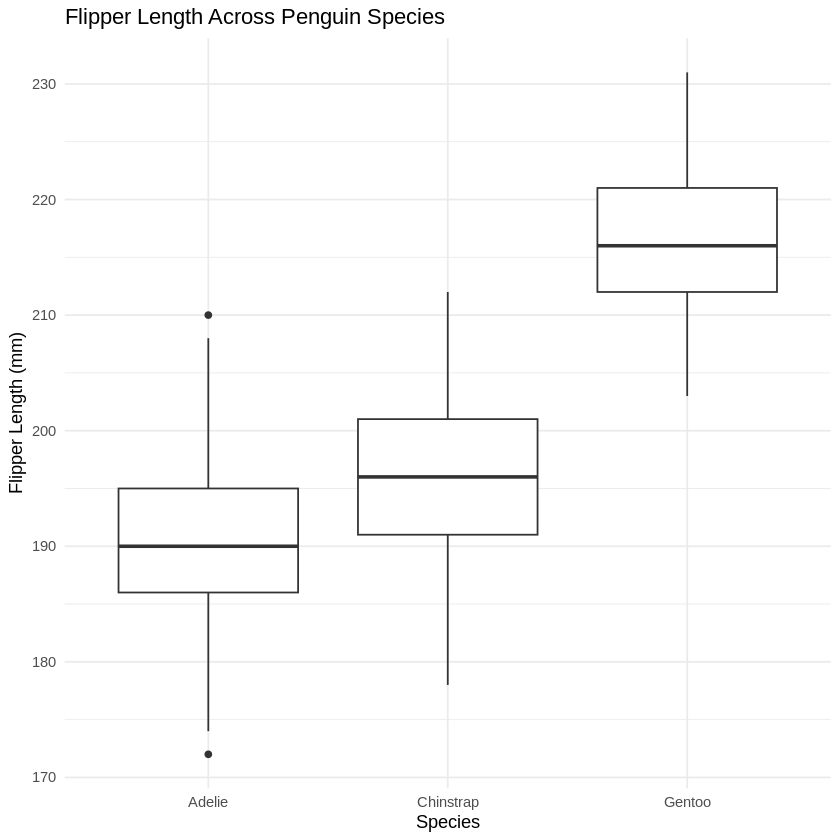

In [31]:
# Flipper length boxplot
ggplot(
  flipper_data,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length Across Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

In [32]:
# Flipper ANOVA
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = flipper_data
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = flipper_data)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


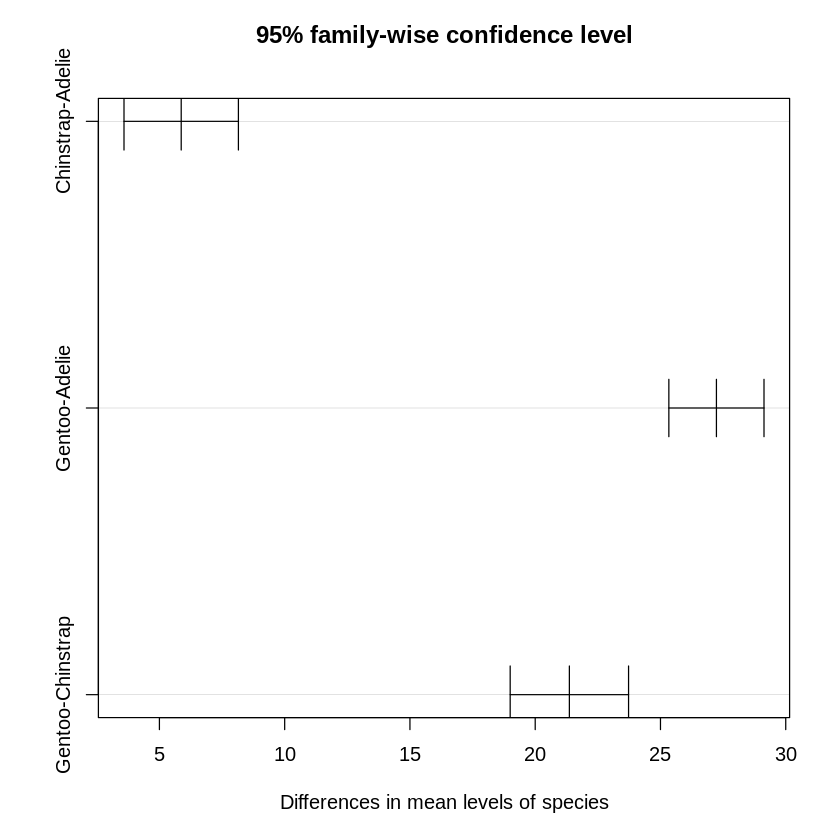

In [34]:
# Flipper Tukey HSD
flipper_tukey <- TukeyHSD(flipper_anova)

flipper_tukey
plot(flipper_tukey)

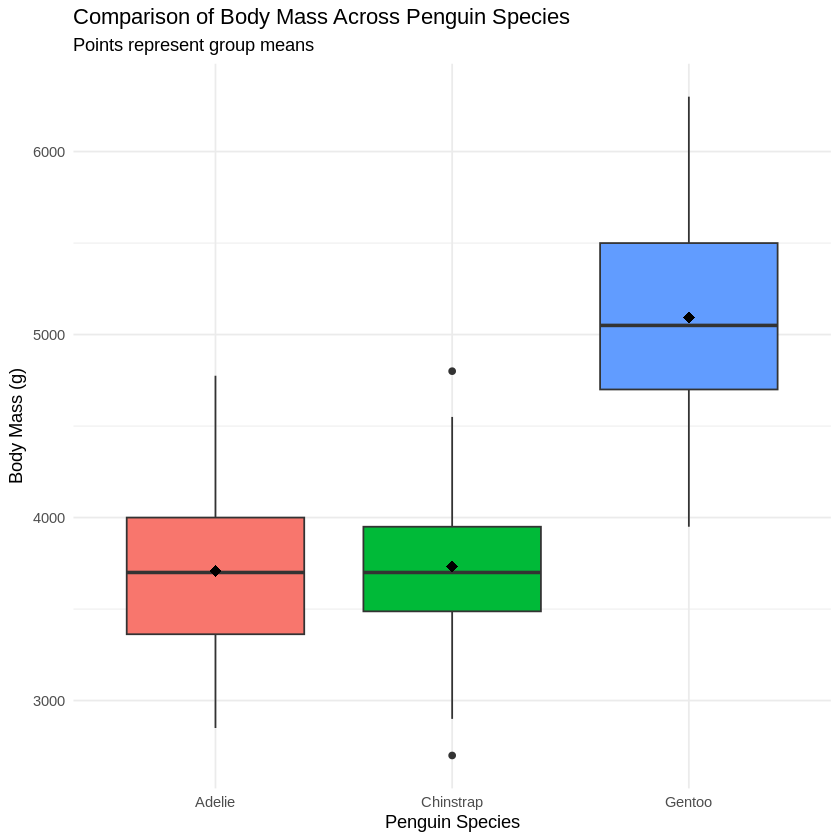

In [35]:
ggplot(
  penguins_clean,
  aes(x = species, y = body_mass_g, fill = species)
) +
  geom_boxplot() +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 18,
    size = 3
  ) +
  labs(
    title = "Comparison of Body Mass Across Penguin Species",
    subtitle = "Points represent group means",
    x = "Penguin Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [36]:
cat(" FINAL ANALYSIS SUMMARY \n\n")

cat("Overall Mean Body Mass:",
    round(mean(penguins_clean$body_mass_g), 2), "g\n")

cat("Male Mean Body Mass:",
    round(mean(male_mass), 2), "g\n")

cat("Female Mean Body Mass:",
    round(mean(female_mass), 2), "g\n")

cat("\nT-test p-value:",
    format.pval(t_test_result$p.value), "\n")

cat("One-way ANOVA p-value:",
    format.pval(anova_p), "\n")

cat("Kruskal-Wallis p-value:",
    format.pval(kruskal_result$p.value), "\n")

cat("\nTwo-way ANOVA:\n")
print(summary(two_way_model))

cat("\nFlipper Length ANOVA:\n")
print(summary(flipper_anova))

 FINAL ANALYSIS SUMMARY 

Overall Mean Body Mass: 4207.06 g
Male Mean Body Mass: 4545.68 g
Female Mean Body Mass: 3862.27 g

T-test p-value: 4.7939e-16 
One-way ANOVA p-value: < 2.22e-16 
Kruskal-Wallis p-value: < 2.22e-16 

Two-way ANOVA:
             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Flipper Length ANOVA:
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Interpretation of Descriptive Statistics

The overall mean body mass of the penguins is **4207.06 g**, while the median is **4050 g**. The minimum and maximum body masses are **2700 g** and **6300 g**, respectively. The standard deviation is **805.22 g**, indicating considerable variation in body mass among the penguins.

The first quartile (Q1) is **3550 g** and the third quartile (Q3) is **4775 g**, giving an interquartile range (IQR) of **1225 g**. Therefore, the middle 50% of penguins have body masses between 3550 g and 4775 g.

The skewness is **0.47**, indicating a moderately positive (right) skew in the overall body-mass distribution. The kurtosis is **2.26**, suggesting that the distribution is slightly less heavy-tailed than a normal distribution.

When analyzed by species, Gentoo penguins have the highest mean body mass (**5092.44 g**), whereas Adelie (**3706.16 g**) and Chinstrap (**3733.09 g**) penguins have considerably lower mean body masses. This indicates that species may be an important factor influencing penguin body mass.


### Interpretation of Male vs Female Body Mass

The objective of this analysis was to determine whether male and female penguins have significantly different mean body masses.

The Shapiro-Wilk tests produced p-values of **1.227 × 10⁻⁷ for males** and **6.155 × 10⁻⁸ for females**. Both p-values are below the significance level of 0.05, indicating evidence against perfect normality. However, the large sample sizes and the visual inspection of the QQ-plots should also be considered when assessing the robustness of the t-test.

The Welch two-sample t-test produced a **t-statistic of -8.55**, with approximately **323.9 degrees of freedom** and a p-value of **4.79 × 10⁻¹⁶**. Since the p-value is far below 0.05, the null hypothesis is rejected.

The mean body mass of female penguins is **3862.27 g**, while the mean body mass of male penguins is **4545.68 g**. Therefore, male penguins have a substantially higher average body mass than female penguins.

The **95% confidence interval for the difference in mean body mass (female − male)** is **[-840.58 g, -526.25 g]**. Since this interval does not contain zero, it provides further evidence of a statistically significant difference between the two groups. The interval suggests that female penguins have, on average, approximately **526 to 841 g lower body mass** than male penguins.

Cohen's d is **-0.94**, with a 95% confidence interval of approximately **[-1.16, -0.71]**. The magnitude of the effect is large, indicating that the difference between male and female body mass is not only statistically significant but also practically substantial.

**Conclusion:** There is strong statistical evidence that male and female penguins differ in body mass, with male penguins having substantially greater mean body mass.


### Interpretation of One-Way ANOVA

A one-way ANOVA was performed to determine whether mean body mass differs among Adelie, Chinstrap, and Gentoo penguins.

Before performing ANOVA, normality was examined using Shapiro-Wilk tests. Adelie penguins produced a p-value of **0.0423**, indicating some evidence of departure from normality at the 5% significance level. Chinstrap and Gentoo produced p-values of **0.5605** and **0.2605**, respectively, providing no significant evidence against normality for those groups. QQ-plots were also used to visually assess the distributions.

Levene's test produced an F-statistic of **5.13** with a p-value of **0.00637**. Since this p-value is below 0.05, the assumption of equal variances is not fully satisfied.

Despite this assumption issue, the one-way ANOVA produced an **F-statistic of 341.9** with **2 and 330 degrees of freedom** and a p-value of **< 2.2 × 10⁻¹⁶**. The p-value is far below 0.05, so the null hypothesis that all three species have the same mean body mass is rejected.

Therefore, there is a statistically significant difference in mean body mass among the three penguin species.

The Tukey HSD post-hoc analysis showed that:

* **Chinstrap vs Adelie:** p = **0.9164**, indicating no significant difference.
* **Gentoo vs Adelie:** p < **0.001**, indicating a significant difference.
* **Gentoo vs Chinstrap:** p < **0.001**, indicating a significant difference.

The results show that the major species-level difference is due to Gentoo penguins having substantially greater body mass than both Adelie and Chinstrap penguins, while Adelie and Chinstrap penguins do not differ significantly in mean body mass.

**Conclusion:** Penguin species has a significant effect on body mass. Gentoo penguins are significantly heavier than both Adelie and Chinstrap penguins, whereas Adelie and Chinstrap have statistically similar mean body masses.


### Interpretation of Kruskal-Wallis Test

Because the normality and equal-variance assumptions were not completely satisfied, the Kruskal-Wallis test was also performed as a non-parametric alternative to one-way ANOVA.

The Kruskal-Wallis test produced a **chi-square statistic of 212.09**, with **2 degrees of freedom**, and a p-value of **< 2.2 × 10⁻¹⁶**.

Since the p-value is far below 0.05, the null hypothesis is rejected. Therefore, there is strong evidence that body mass differs among the three penguin species.

The Kruskal-Wallis test reaches the same overall conclusion as the one-way ANOVA. Both methods indicate statistically significant differences in body mass across species.

**Conclusion:** The agreement between the parametric ANOVA and the non-parametric Kruskal-Wallis test provides strong evidence that the observed differences in body mass among penguin species are not simply a consequence of violations of the ANOVA assumptions.


### Interpretation of Two-Way ANOVA

A two-way ANOVA was performed using the model:

**body_mass_g ~ species * sex**

This model examines the individual effects of species and sex as well as their interaction.

The effect of **species** was statistically significant, with an F-statistic of **758.358** and a p-value of **< 2 × 10⁻¹⁶**. Therefore, species has a significant effect on penguin body mass.

The effect of **sex** was also statistically significant, with an F-statistic of **387.460** and a p-value of **< 2 × 10⁻¹⁶**. Therefore, male and female penguins differ significantly in body mass even after accounting for species.

The **species × sex interaction** was statistically significant, with an F-statistic of **8.757** and a p-value of **0.000197**. This indicates that the effect of sex on body mass is not exactly the same across all penguin species.

The significant interaction means that the difference between male and female body mass varies depending on the penguin species.

**Conclusion:** Both species and sex have significant effects on body mass, and their significant interaction indicates that the relationship between sex and body mass depends to some extent on species.


### Interpretation of Flipper Length Analysis

Flipper length was analyzed to determine whether it varies significantly among the three penguin species.

The mean flipper lengths were:

* **Adelie:** 189.95 mm
* **Chinstrap:** 195.82 mm
* **Gentoo:** 217.19 mm

Gentoo penguins therefore have the largest average flipper length, while Adelie penguins have the smallest.

The one-way ANOVA produced an **F-statistic of 594.8** with **2 and 339 degrees of freedom** and a p-value of **< 2.2 × 10⁻¹⁶**. Since the p-value is far below 0.05, the null hypothesis is rejected.

Thus, mean flipper length differs significantly among the three species.

The Tukey HSD analysis showed significant differences for all three pairwise comparisons:

* **Chinstrap − Adelie:** difference ≈ **5.87 mm**, p < 0.001
* **Gentoo − Adelie:** difference ≈ **27.23 mm**, p < 0.001
* **Gentoo − Chinstrap:** difference ≈ **21.36 mm**, p < 0.001

Therefore, every species pair has a statistically significant difference in mean flipper length.

**Conclusion:** Flipper length varies significantly among all three penguin species. Gentoo penguins have substantially longer flippers than both Adelie and Chinstrap penguins. These findings are consistent with the body-mass analysis, where Gentoo penguins also showed substantially higher body mass.


# Overall Statistical Conclusion

The statistical analysis of the Palmer Penguins dataset demonstrates clear differences in physical characteristics among penguin species and between sexes.

The descriptive analysis showed that Gentoo penguins have substantially greater body mass than Adelie and Chinstrap penguins. The overall body-mass distribution showed moderate positive skewness, while the species-wise statistics demonstrated clear differences in central tendency and spread.

The independent Welch t-test showed a highly significant difference between male and female body mass (**p = 4.79 × 10⁻¹⁶**). Male penguins had a mean body mass of **4545.68 g**, compared with **3862.27 g** for females. The 95% confidence interval for the female-minus-male difference was **[-840.58, -526.25] g**, and Cohen's d was **-0.94**, indicating a large practical effect.

The one-way ANOVA also showed a highly significant difference in body mass among species (**F(2,330) = 341.9, p < 2.2 × 10⁻¹⁶**). Tukey's HSD showed that Gentoo penguins differed significantly from both Adelie and Chinstrap penguins, while the difference between Adelie and Chinstrap was not statistically significant.

Although some ANOVA assumptions were not completely satisfied, the Kruskal-Wallis test produced the same overall conclusion (**χ²(2) = 212.09, p < 2.2 × 10⁻¹⁶**), strengthening the evidence for significant species-level differences.

The two-way ANOVA demonstrated that both species and sex significantly affect body mass. Importantly, the significant species × sex interaction (**F(2,327) = 8.757, p = 0.000197**) indicates that the difference between males and females varies somewhat across species.

The analysis of flipper length produced similar findings. Mean flipper length was highest for Gentoo penguins (**217.19 mm**), followed by Chinstrap (**195.82 mm**) and Adelie (**189.95 mm**). The one-way ANOVA showed a highly significant species effect (**F(2,339) = 594.8, p < 2.2 × 10⁻¹⁶**), and Tukey's test indicated significant differences between every pair of species.

Overall, the results provide strong statistical evidence that **penguin species and sex are important factors associated with physical characteristics such as body mass and flipper length**. Gentoo penguins consistently exhibit larger body mass and longer flippers than the other two species, while males generally have substantially greater body mass than females.
